In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("Setup successful!")

TensorFlow version: 2.20.0
Setup successful!


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")

print("Project exists:", os.path.exists(PROJECT_DIR))
print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Dataset contents:", os.listdir(DATASET_DIR))

Project exists: True
Dataset exists: True
Dataset contents: ['Epic and CSCR hospital Dataset']


In [ ]:
DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "Epic and CSCR hospital Dataset"
)

print("Dataset path:", DATASET_DIR)
print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Contents:")
print(os.listdir(DATASET_DIR))

Dataset path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset
Dataset exists: True
Contents:
['Test', 'Train']


In [ ]:
TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

print("Train contents:", os.listdir(TRAIN_DIR))
print("Test contents:", os.listdir(TEST_DIR))

Train contents: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test contents: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import glob

image_paths = []
labels = []

class_mapping = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

for class_name, label in class_mapping.items():
    class_dir = os.path.join(TRAIN_DIR, class_name)

    for img_path in glob.glob(os.path.join(class_dir, "*")):
        image_paths.append(img_path)
        labels.append(label)

print("Total training images:", len(image_paths))
print("Tumourous images:", sum(labels))
print("Non-Tumourous images:", len(labels) - sum(labels))

Total training images: 9650
Tumourous images: 7705
Non-Tumourous images: 1945


In [ ]:
train_df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Training images: 7720
Validation images: 1930

Training distribution:
label
1    6164
0    1556
Name: count, dtype: int64

Validation distribution:
label
1    1541
0     389
Name: count, dtype: int64


In [ ]:
test_image_paths = []
test_labels = []

for class_name, label in class_mapping.items():
    class_dir = os.path.join(TEST_DIR, class_name)

    for img_path in glob.glob(os.path.join(class_dir, "*")):
        test_image_paths.append(img_path)
        test_labels.append(label)

test_df = pd.DataFrame({
    "image_path": test_image_paths,
    "label": test_labels
})

print("Total test images:", len(test_df))
print("\nTest distribution:")
print(test_df["label"].value_counts())

Total test images: 2414

Test distribution:
label
1    1927
0     487
Name: count, dtype: int64


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

print("Preprocessing function ready!")

Preprocessing function ready!


In [ ]:
def create_dataset(df, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (df["image_path"].values, df["label"].values)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_dataset = create_dataset(train_df, shuffle=True)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Train batches: 242
Validation batches: 61
Test batches: 76


In [ ]:
images, labels_batch = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels_batch.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())
print("Labels:", labels_batch[:10].numpy())

In [ ]:
import tensorflow as tf

print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
classes = np.array([0, 1])

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(classes, class_weights_values))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(2.480719794344473), np.int64(1): np.float64(0.6262167423750811)}


In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("EfficientNetB0 loaded!")
print("Trainable:", base_model.trainable)

EfficientNetB0 loaded!
Trainable: False


In [ ]:
from tensorflow.keras import layers, models

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

print("Transfer learning model created!")

Transfer learning model created!


In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
transfer_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

early_stopping_tl = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_tl = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_DIR, "best_efficientnetb0.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr_tl = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [ ]:
history_tl = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stopping_tl,
        checkpoint_tl,
        reduce_lr_tl
    ],
    verbose=1
)

Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4826 - loss: 0.7038 - precision: 0.7887 - recall: 0.4777
Epoch 1: val_loss improved from None to 0.68337, saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_efficientnetb0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_efficientnetb0.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 198ms/step - accuracy: 0.4886 - loss: 0.6984 - precision: 0.7952 - recall: 0.4843 - val_accuracy: 0.7984 - val_loss: 0.6834 - val_precision: 0.7984 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
241/242 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4923 - loss: 0.7014 - precision: 0.7886 - recall: 0.4950
Epoch 2: val_loss did not improve from 0.68337
242/242 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.4999 - loss: 0.6996 - precision: 0.7964 - recall: 0.5019 - val_accuracy: 0.2016 - val_loss: 0.7092 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lea

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "Epic and CSCR hospital Dataset"
)

print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Dataset path:", DATASET_DIR)

Dataset exists: True
Dataset path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset


In [ ]:
import shutil
import os

LOCAL_DATASET_DIR = "/content/brain_tumor_dataset"

if not os.path.exists(LOCAL_DATASET_DIR):
    print("Copying dataset to Colab local storage...")
    shutil.copytree(DATASET_DIR, LOCAL_DATASET_DIR)
    print("Dataset copied successfully!")
else:
    print("Local dataset already exists!")

print("Local dataset path:", LOCAL_DATASET_DIR)

Copying dataset to Colab local storage...
Dataset copied successfully!
Local dataset path: /content/brain_tumor_dataset


In [ ]:
TRAIN_DIR = os.path.join(LOCAL_DATASET_DIR, "Train")
TEST_DIR = os.path.join(LOCAL_DATASET_DIR, "Test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))
print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Train exists: True
Test exists: True
Train classes: ['pituitary', 'notumor', 'glioma', 'meningioma']
Test classes: ['pituitary', 'notumor', 'glioma', 'meningioma']


In [ ]:
import glob

class_mapping = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

image_paths = []
labels = []

for class_name, label in class_mapping.items():
    class_dir = os.path.join(TRAIN_DIR, class_name)

    for img_path in glob.glob(os.path.join(class_dir, "*")):
        image_paths.append(img_path)
        labels.append(label)

print("Total training images:", len(image_paths))
print("Tumourous images:", sum(labels))
print("Non-Tumourous images:", len(labels) - sum(labels))

Total training images: 9650
Tumourous images: 7705
Non-Tumourous images: 1945


In [ ]:
train_df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

NameError: name 'pd' is not defined

In [ ]:
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Local dataset exists:", os.path.exists("/content/brain_tumor_dataset"))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Local dataset exists: True


In [ ]:
LOCAL_DATASET_DIR = "/content/brain_tumor_dataset"

TRAIN_DIR = os.path.join(LOCAL_DATASET_DIR, "Train")
TEST_DIR = os.path.join(LOCAL_DATASET_DIR, "Test")

class_mapping = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))
print("Classes:", os.listdir(TRAIN_DIR))

Train exists: True
Test exists: True
Classes: ['pituitary', 'notumor', 'glioma', 'meningioma']


In [ ]:
image_paths = []
labels = []

for class_name, label in class_mapping.items():
    class_dir = os.path.join(TRAIN_DIR, class_name)

    for img_path in glob.glob(os.path.join(class_dir, "*")):
        image_paths.append(img_path)
        labels.append(label)

print("Total training images:", len(image_paths))
print("Tumourous images:", sum(labels))
print("Non-Tumourous images:", len(labels) - sum(labels))

Total training images: 9650
Tumourous images: 7705
Non-Tumourous images: 1945


In [ ]:
train_df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Training images: 7720
Validation images: 1930

Training distribution:
label
1    6164
0    1556
Name: count, dtype: int64

Validation distribution:
label
1    1541
0     389
Name: count, dtype: int64


In [ ]:
test_image_paths = []
test_labels = []

for class_name, label in class_mapping.items():
    class_dir = os.path.join(TEST_DIR, class_name)

    for img_path in glob.glob(os.path.join(class_dir, "*")):
        test_image_paths.append(img_path)
        test_labels.append(label)

test_df = pd.DataFrame({
    "image_path": test_image_paths,
    "label": test_labels
})

print("Total test images:", len(test_df))
print("\nTest distribution:")
print(test_df["label"].value_counts())

Total test images: 2414

Test distribution:
label
1    1927
0     487
Name: count, dtype: int64


In [ ]:
# EfficientNet ke upper layers ko fine-tuning ke liye unfreeze karna
base_model.trainable = True

# Sirf last ~20 layers ko trainable rakhenge
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 238
Trainable layers: 20


In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Fine-tuning model compiled successfully!")

Fine-tuning model compiled successfully!


In [ ]:
history_ft = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stopping_tl,
        checkpoint_tl,
        reduce_lr_tl
    ],
    verbose=1
)

Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4251 - loss: 0.7049 - precision: 0.7950 - recall: 0.3643
Epoch 1: val_loss did not improve from 0.65769
242/242 ━━━━━━━━━━━━━━━━━━━━ 92s 184ms/step - accuracy: 0.5142 - loss: 0.6931 - precision: 0.8127 - recall: 0.5089 - val_accuracy: 0.7984 - val_loss: 0.6636 - val_precision: 0.7984 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
241/242 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5315 - loss: 0.6887 - precision: 0.8338 - recall: 0.5133
Epoch 2: val_loss did not improve from 0.65769

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
242/242 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.5627 - loss: 0.6831 - precision: 0.8427 - recall: 0.5561 - val_accuracy: 0.8694 - val_loss: 0.6733 - val_precision: 0.8834 - val_recall: 0.9637 - learning_rate: 1.0000e-05
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5930 - loss: 0.6759 - precision: 0.8544 - recall: 0.5

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_efficientnetb0.keras"
)

test_results = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results:")
for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 28s 223ms/step - accuracy: 0.7983 - loss: 0.6575 - precision: 0.7983 - recall: 1.0000

Test Results:
loss: 0.6575
compile_metrics: 0.7983


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = test_df["label"].values

y_prob = best_model.predict(test_dataset, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Non-Tumour", "Tumour"],
        digits=4
    )
)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step
Classification Report:

              precision    recall  f1-score   support

  Non-Tumour     0.0000    0.0000    0.0000       487
      Tumour     0.7983    1.0000    0.8878      1927

    accuracy                         0.7983      2414
   macro avg     0.3991    0.5000    0.4439      2414
weighted avg     0.6372    0.7983    0.7087      2414


Confusion Matrix:

[[   0  487]
 [   0 1927]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_prob = best_model.predict(test_dataset, verbose=1).ravel()

print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

print("\nFirst 20 probabilities:")
print(y_prob[:20])

76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step
Minimum probability: 0.52027255
Maximum probability: 0.5318303
Mean probability: 0.53041756

First 20 probabilities:
[0.5314599  0.5308714  0.530614   0.5305204  0.5309426  0.53140545
 0.5307664  0.53120065 0.530835   0.53103393 0.5305661  0.53130394
 0.5305991  0.5312222  0.5310791  0.5307839  0.5308715  0.53098315
 0.5309977  0.5312243 ]


In [ ]:
# Validation probability check
val_prob = best_model.predict(val_dataset, verbose=1).ravel()

print("Validation Minimum:", val_prob.min())
print("Validation Maximum:", val_prob.max())
print("Validation Mean:", val_prob.mean())

print("\nFirst 20 validation probabilities:")
print(val_prob[:20])

61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step
Validation Minimum: 0.52332723
Validation Maximum: 0.53193
Validation Mean: 0.530639

First 20 validation probabilities:
[0.5307844  0.53104854 0.5308867  0.530753   0.5306706  0.53125453
 0.5307918  0.5259763  0.5300582  0.52792084 0.53147566 0.53050953
 0.5310494  0.53126866 0.53018093 0.5307881  0.5314553  0.52959174
 0.53082794 0.5306708 ]


In [ ]:
# Fresh EfficientNetB0 model - WITHOUT class weights

base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

transfer_model_v2 = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

transfer_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

transfer_model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_v2 = transfer_model_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[
        early_stopping_tl,
        checkpoint_tl,
        reduce_lr_tl
    ],
    verbose=1
)

Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7905 - loss: 0.5482 - precision: 0.8064 - recall: 0.9752
Epoch 1: val_loss improved from 0.65769 to 0.50279, saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_efficientnetb0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_efficientnetb0.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 81s 175ms/step - accuracy: 0.7946 - loss: 0.5254 - precision: 0.7981 - recall: 0.9942 - val_accuracy: 0.7984 - val_loss: 0.5028 - val_precision: 0.7984 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7988 - loss: 0.5051 - precision: 0.7988 - recall: 1.0000
Epoch 2: val_loss did not improve from 0.50279
242/242 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.7984 - loss: 0.5059 - precision: 0.7984 - recall: 1.0000 - val_accuracy: 0.7984 - val_loss: 0.5028 - val_precision: 0.7984 - val_recall: 1.0000 - learning_

In [ ]:
import os
from PIL import Image

def check_dataset(folder):
    total = 0
    corrupted = []
    blank_or_low_std = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                total += 1

                try:
                    img = Image.open(path).convert("RGB")
                    img.load()

                    # Basic image quality check
                    import numpy as np
                    arr = np.array(img)

                    if arr.std() < 5:
                        blank_or_low_std.append(path)

                except Exception:
                    corrupted.append(path)

    return total, corrupted, blank_or_low_std


train_total, train_corrupt, train_low = check_dataset(
    os.path.join(LOCAL_DATASET_DIR, "Train")
)

test_total, test_corrupt, test_low = check_dataset(
    os.path.join(LOCAL_DATASET_DIR, "Test")
)

print("===== DATASET QUALITY CHECK =====")
print(f"Train images: {train_total}")
print(f"Train corrupted: {len(train_corrupt)}")
print(f"Train blank/very-low variation: {len(train_low)}")

print()

print(f"Test images: {test_total}")
print(f"Test corrupted: {len(test_corrupt)}")
print(f"Test blank/very-low variation: {len(test_low)}")

===== DATASET QUALITY CHECK =====
Train images: 9650
Train corrupted: 0
Train blank/very-low variation: 0

Test images: 2414
Test corrupted: 0
Test blank/very-low variation: 0


In [ ]:
# Check actual pixel values going into EfficientNet

for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())
    print("Pixel mean:", tf.reduce_mean(images).numpy())
    print("Pixel std:", tf.math.reduce_std(images).numpy())
    print("Labels:", labels[:20].numpy())

Image shape: (32, 224, 224, 3)
Pixel minimum: 0.0
Pixel maximum: 1.0
Pixel mean: 0.18741506
Pixel std: 0.19157322
Labels: [1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1]


In [ ]:
print("Preprocess function:")
print(preprocess_image)

print("\nDataset element spec:")
print(train_dataset.element_spec)

Preprocess function:
<function preprocess_image at 0x7c07ffe1bce0>

Dataset element spec:
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))


In [ ]:
import inspect

print(inspect.getsource(preprocess_image))

def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label



In [ ]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

In [ ]:
def create_dataset(df, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (df["image_path"].values, df["label"].values)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


# Recreate datasets with corrected preprocessing
train_dataset = create_dataset(train_df, shuffle=True)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

print("Datasets recreated successfully!")
print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Datasets recreated successfully!
Train batches: 242
Val batches: 61
Test batches: 76


In [ ]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())
    print("Pixel mean:", tf.reduce_mean(images).numpy())
    print("Pixel std:", tf.math.reduce_std(images).numpy())

NameError: name 'train_dataset' is not defined

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset"

print("Actual dataset:", DATASET_DIR)
print("Contents:", os.listdir(DATASET_DIR))
print("Train exists:", os.path.exists(os.path.join(DATASET_DIR, "Train")))
print("Test exists:", os.path.exists(os.path.join(DATASET_DIR, "Test")))

Actual dataset: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset
Contents: ['Test', 'Train']
Train exists: True
Test exists: True


In [ ]:
import os
import pandas as pd

CLASS_MAPPING = {
    "notumor": 0,
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1
}

def collect_images(split):
    rows = []

    split_dir = os.path.join(DATASET_DIR, split)

    for class_name, label in CLASS_MAPPING.items():
        class_dir = os.path.join(split_dir, class_name)

        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append({
                    "image_path": os.path.join(class_dir, file_name),
                    "label": label
                })

    return pd.DataFrame(rows)

train_df = collect_images("Train")
test_df = collect_images("Test")

print("Train images:", len(train_df))
print("Test images:", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts().sort_index())

print("\nTest labels:")
print(test_df["label"].value_counts().sort_index())

Train images: 9650
Test images: 2414

Train labels:
label
0    1945
1    7705
Name: count, dtype: int64

Test labels:
label
0     487
1    1927
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining labels:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation labels:")
print(val_df["label"].value_counts().sort_index())

Training images: 7720
Validation images: 1930

Training labels:
label
0    1556
1    6164
Name: count, dtype: int64

Validation labels:
label
0     389
1    1541
Name: count, dtype: int64


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def create_dataset(df, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            df["image_path"].values,
            df["label"].values.astype("int32")
        )
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=4
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(1)

    return dataset


train_dataset = create_dataset(train_df, shuffle=True)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Train batches: 242
Val batches: 61
Test batches: 76


In [ ]:
Train batches: 242
Val batches: 61
Test batches: 76

SyntaxError: invalid syntax (1110699236.py, line 1)

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Pixel min:", tf.reduce_min(images).numpy())
    print("Pixel max:", tf.reduce_max(images).numpy())
    print("Pixel mean:", tf.reduce_mean(images).numpy())

Image shape: (32, 224, 224, 3)
Pixel min: 0.0
Pixel max: 255.0
Pixel mean: 52.35849


In [ ]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_tl = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[
        early_stopping_tl,
        reduce_lr_tl
    ],
    verbose=1
)

Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 108s 296ms/step - accuracy: 0.7674 - loss: 0.4752 - precision: 0.8148 - recall: 0.9171 - val_accuracy: 0.8212 - val_loss: 0.3552 - val_precision: 0.8191 - val_recall: 0.9961 - learning_rate: 1.0000e-04
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0.8521 - loss: 0.3386 - precision: 0.8573 - recall: 0.9774 - val_accuracy: 0.8876 - val_loss: 0.2818 - val_precision: 0.8844 - val_recall: 0.9883 - learning_rate: 1.0000e-04
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0.8939 - loss: 0.2810 - precision: 0.8998 - recall: 0.9758 - val_accuracy: 0.9176 - val_loss: 0.2400 - val_precision: 0.9148 - val_recall: 0.9890 - learning_rate: 1.0000e-04
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.9161 - loss: 0.2433 - precision: 0.9216 - recall: 0.9781 - val_accuracy: 0.9326 - val_loss: 0.2130 - val_precision: 0.9315 - val_recall: 0.9883 - learning_rate: 1.0000e-04
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━

In [ ]:
early_stopping_tl = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
test_results = transfer_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n===== EfficientNetB0 Test Results =====")
print(f"Test Loss:      {test_results[0]:.4f}")
print(f"Test Accuracy:  {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall:    {test_results[3]:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 25s 330ms/step - accuracy: 0.9573 - loss: 0.1285 - precision: 0.9701 - recall: 0.9766

===== EfficientNetB0 Test Results =====
Test Loss:      0.1285
Test Accuracy:  0.9573
Test Precision: 0.9701
Test Recall:    0.9766


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_true = np.concatenate([y.numpy() for _, y in test_dataset])
y_prob = transfer_model.predict(test_dataset, verbose=1).ravel()

# 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

print("===== Classification Report =====")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Non-Tumour", "Tumour"],
        digits=4
    )
)

print("\n===== Confusion Matrix =====")
print(confusion_matrix(y_true, y_pred))

76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 184ms/step
===== Classification Report =====
              precision    recall  f1-score   support

  Non-Tumour     0.9051    0.8809    0.8928       487
      Tumour     0.9701    0.9766    0.9734      1927

    accuracy                         0.9573      2414
   macro avg     0.9376    0.9288    0.9331      2414
weighted avg     0.9570    0.9573    0.9571      2414


===== Confusion Matrix =====
[[ 429   58]
 [  45 1882]]


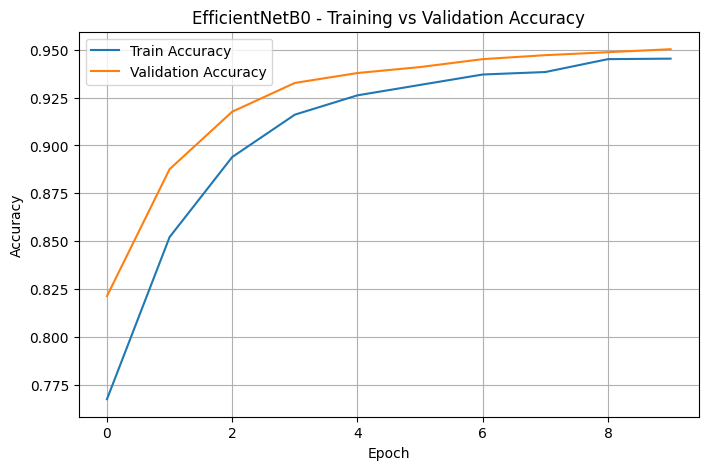

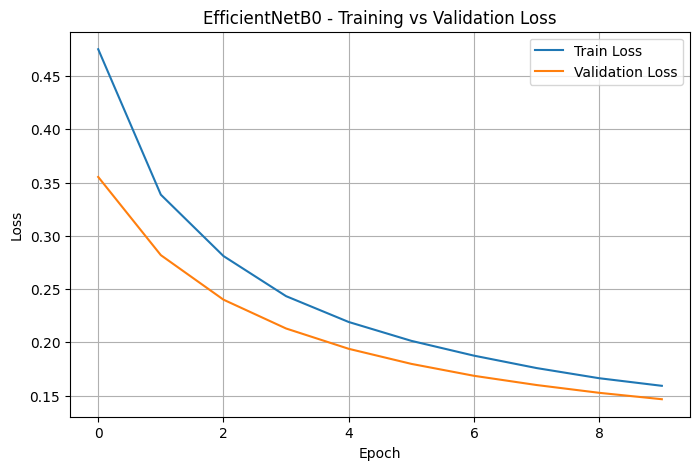

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_tl.history["accuracy"], label="Train Accuracy")
plt.plot(history_tl.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Loss
plt.figure(figsize=(8, 5))
plt.plot(history_tl.history["loss"], label="Train Loss")
plt.plot(history_tl.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

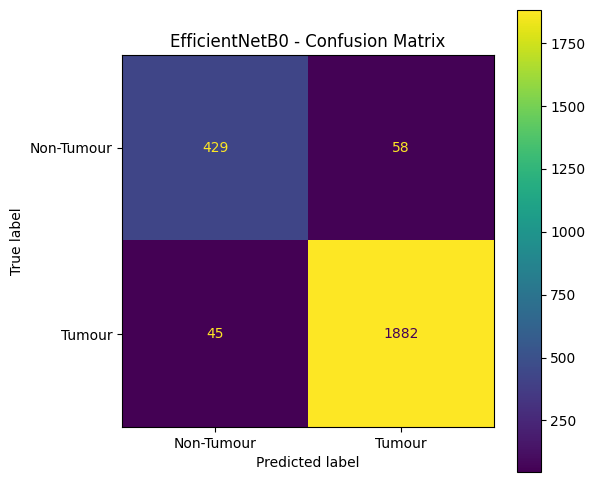

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Tumour", "Tumour"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
ax.set_title("EfficientNetB0 - Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Tumour F1-Score"
    ],
    "Custom CNN": [
        0.9689,
        0.9989,
        0.9621,
        None
    ],
    "EfficientNetB0": [
        0.9573,
        0.9701,
        0.9766,
        0.9734
    ]
})

comparison["Custom CNN"] = comparison["Custom CNN"].apply(
    lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A"
)

comparison["EfficientNetB0"] = comparison["EfficientNetB0"].apply(
    lambda x: f"{x*100:.2f}%"
)

comparison


,Metric,Custom CNN,EfficientNetB0
0,Accuracy,96.89%,95.73%
1,Precision,99.89%,97.01%
2,Recall,96.21%,97.66%
3,Tumour F1-Score,N/A,97.34%


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project/models"

import os
os.makedirs(MODEL_DIR, exist_ok=True)

transfer_model.save(
    os.path.join(MODEL_DIR, "efficientnetb0_final.keras")
)

print("EfficientNetB0 saved successfully!")
print(os.path.join(MODEL_DIR, "efficientnetb0_final.keras"))

EfficientNetB0 saved successfully!
/content/drive/MyDrive/Brain_Tumor_CNN_Project/models/efficientnetb0_final.keras


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/Brain_Tumor_CNN_Project/models/efficientnetb0_final.keras"

model = load_model(MODEL_PATH)

def predict_mri(image_path):
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)

    # Add batch dimension
    input_image = tf.expand_dims(image, axis=0)

    # Prediction
    probability = model.predict(input_image, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "Tumour"
        confidence = probability * 100
    else:
        prediction = "Non-Tumour"
        confidence = (1 - probability) * 100

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(tf.cast(image, tf.uint8))
    plt.axis("off")
    plt.title(f"Prediction: {prediction}\nConfidence: {confidence:.2f}%")
    plt.show()

    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")
    print(f"Raw probability: {probability:.4f}")

Image path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset/Test/glioma/1359.jpg
Actual label: Tumour


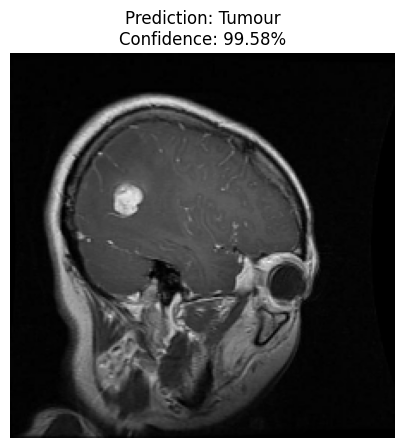

Prediction: Tumour
Confidence: 99.58%
Raw probability: 0.9958


In [ ]:
# Pick one image from the test dataset
sample_row = test_df.sample(1, random_state=42).iloc[0]

sample_path = sample_row["image_path"]
actual_label = sample_row["label"]

print("Image path:", sample_path)
print("Actual label:", "Tumour" if actual_label == 1 else "Non-Tumour")

# Predict
predict_mri(sample_path)

Actual label: Non-Tumour
Image path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset/Test/notumor/1180.jpg


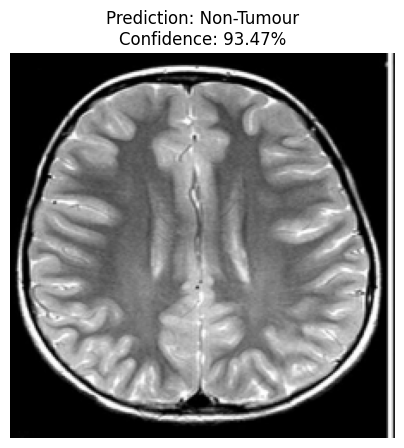

Prediction: Non-Tumour
Confidence: 93.47%
Raw probability: 0.0653


In [ ]:
# Find one Non-Tumour image from the test set
non_tumour_samples = test_df[test_df["label"] == 0]

sample_row = non_tumour_samples.sample(1, random_state=42).iloc[0]

sample_path = sample_row["image_path"]

print("Actual label: Non-Tumour")
print("Image path:", sample_path)

predict_mri(sample_path)